In [1]:
# ── 1. Imports ──────────────────────────────────────────────
import pandas as pd
import pickle
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import matplotlib.pyplot as plt

In [2]:
# ── 2. Cargar dataset desde UCI ─────────────────────────────
data = fetch_ucirepo(id=17)
X = data.data.features
y = data.data.targets["Diagnosis"]

In [ ]:
# ── 3. Codificar target ─────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(y)         # Maligno: 1, Benigno: 0

In [4]:
# ── 4. Split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

In [5]:
# ── 5. Escalar ──────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [6]:
# ── 6. Modelo + búsqueda de hiperparámetros ─────────────────
mlp = MLPClassifier(max_iter=10000, random_state=42)

param_grid = {
    "hidden_layer_sizes": [(30,), (64,), (30, 15), (64, 32)],
    "activation"        : ["relu", "tanh"],
    "alpha"             : [0.001, 0.01, 0.1]
}
# hidden_layer_sizes ahora tiene capas más grandes
# acordes a los 30 features del dataset

grid_search = RandomizedSearchCV(
    mlp, param_grid, cv=5, n_jobs=-1,
    scoring="accuracy", random_state=42, n_iter=10)
grid_search.fit(X_train_sc, y_train)

best_model = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'hidden_layer_sizes': (64,), 'alpha': 0.1, 'activation': 'relu'}


Accuracy : 0.9766081871345029
Precision: 0.9682539682539683
Recall   : 0.9682539682539683
F1-Score : 0.9682539682539683


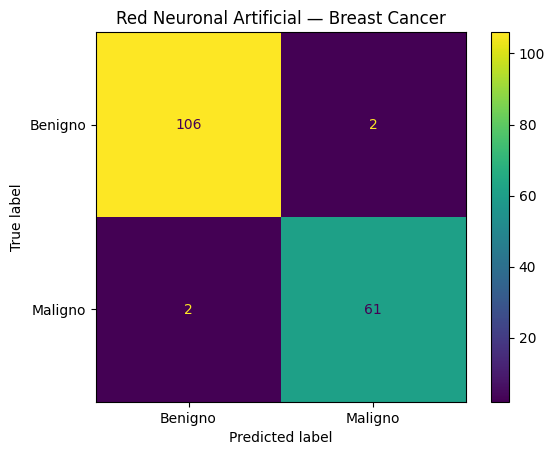

In [7]:
# ── 7. Métricas ─────────────────────────────────────────────
y_pred = best_model.predict(X_test_sc)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Benigno","Maligno"]).plot()
plt.title("Red Neuronal Artificial — Breast Cancer")
plt.show()

In [8]:

# ── 8. Guardar modelo + scaler ──────────────────────────────
with open("guardados/modelo_mlp.pkl",  "wb") as f: pickle.dump(best_model, f)
with open("guardados/scaler_mlp.pkl",  "wb") as f: pickle.dump(scaler, f)

print("Modelo RNA guardado")

Modelo RNA guardado
